# Publication Figures
**Duck Egg Fertility Detection — K-Means & Fuzzy C-Means with U-Net Deep Embedding Features**

Figures generated:
| File | Description |
|------|-------------|
| `docs/fig_prediction_detail.png` | Test-set prediction grid (correct / wrong) |
| `docs/fig_tsne_cluster.png` | t-SNE of 73-D hybrid feature space |
| `docs/fig_repeated_cv.png` | Repeated Stratified 5-Fold CV (10×5=50 evals) |
| `docs/fig_eval_protocol.png` | Evaluation protocol diagram |
| `docs/fig_ablation.png` | Ablation study — U-Net feature contribution |
| `docs/fig_08a_mcnemar.png` | McNemar Exact Test (n=24 test images) |
| `docs/fig_08b_bootstrap.png` | Bootstrap CI + Permutation Test (n=24) |
| `docs/fig_08c_summary.png` | Statistical validation summary table |

> Run cells top-to-bottom. **Cell 2 (Setup) must run first** — all other cells depend on it.

In [53]:
# ── Working directory ────────────────────────────────────────────────────
import os, pathlib
# If running from notebooks/, go up one level to project root
if pathlib.Path.cwd().name == "notebooks":
    os.chdir("..")
print("Working dir:", os.getcwd())

Working dir: c:\Users\vanguard\OneDrive\Documents\duck_egg_fertility_detection


In [54]:
# ── Imports & global style ───────────────────────────────────────────────
import sys, math, warnings
sys.path.insert(0, ".")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import pickle
import cv2

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines

from scipy.stats import binom, wilcoxon, ttest_rel
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    RepeatedStratifiedKFold, StratifiedKFold
)

from src.clustering.fuzzy_cmeans import FuzzyCMeans
from src.clustering.kmeans_baseline import KMeansBaseline

# ── Global color palette ─────────────────────────────────────────────────
BG    = "#FAFAFA"
C_FCM = "#2A9D8F"   # teal  — Fuzzy C-Means
C_KM  = "#F4A261"   # amber — K-Means
C_OK  = "#2E7D32"   # green
C_ERR = "#C62828"   # red
ALPHA = 0.05

plt.rcParams["figure.facecolor"] = BG
plt.rcParams["axes.facecolor"]   = BG
print("Imports OK")

Imports OK


In [55]:
# ── Load features, labels, models ───────────────────────────────────────
X_tr  = np.load("data/features/awc_features.npy")        # (156, 73)
y_tr  = np.load("data/features/awc_labels.npy")          # (156,)
X_te  = np.load("data/features/awc_test_features.npy")   # (24, 73)
y_te  = np.load("data/features/awc_test_labels.npy")     # (24,)
X_all = np.vstack([X_tr, X_te])   # (180, 73)
y_all = np.hstack([y_tr, y_te])   # (180,)

with open("models/baselines/fcm_model.pkl", "rb") as f:
    fcm_model = pickle.load(f)
with open("models/baselines/kmeans_model.pkl", "rb") as f:
    km_model  = pickle.load(f)

# Test-set predictions (n=24)
fcm_te = fcm_model.predict(X_te)
km_te  = km_model.predict(X_te)
ca     = (fcm_te == y_te)   # FCM correct per sample
cb     = (km_te  == y_te)   # KM  correct per sample

# CSV with image names + labels (for prediction grid)
df_all  = pd.read_csv("results/evaluation/full_evaluation_predictions.csv")
df_test = df_all[df_all["split"] == "test"].copy().reset_index(drop=True)
df_test["fcm_ok"] = df_test["FCM"]    == df_test["true_label"]
df_test["km_ok"]  = df_test["KMeans"] == df_test["true_label"]

PRE = pathlib.Path("data/preprocessed/test")

def load_img(fname, label):
    p   = PRE / label / fname
    img = cv2.imread(str(p))
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img is not None \
           else np.zeros((256, 256, 3), np.uint8)

print(f"Train: {X_tr.shape}  Test: {X_te.shape}")
print(f"FCM test acc: {ca.mean():.3f}  KM test acc: {cb.mean():.3f}")

Train: (156, 73)  Test: (24, 73)
FCM test acc: 0.833  KM test acc: 0.792


---
## Fig 1 — Test-Set Prediction Outcomes

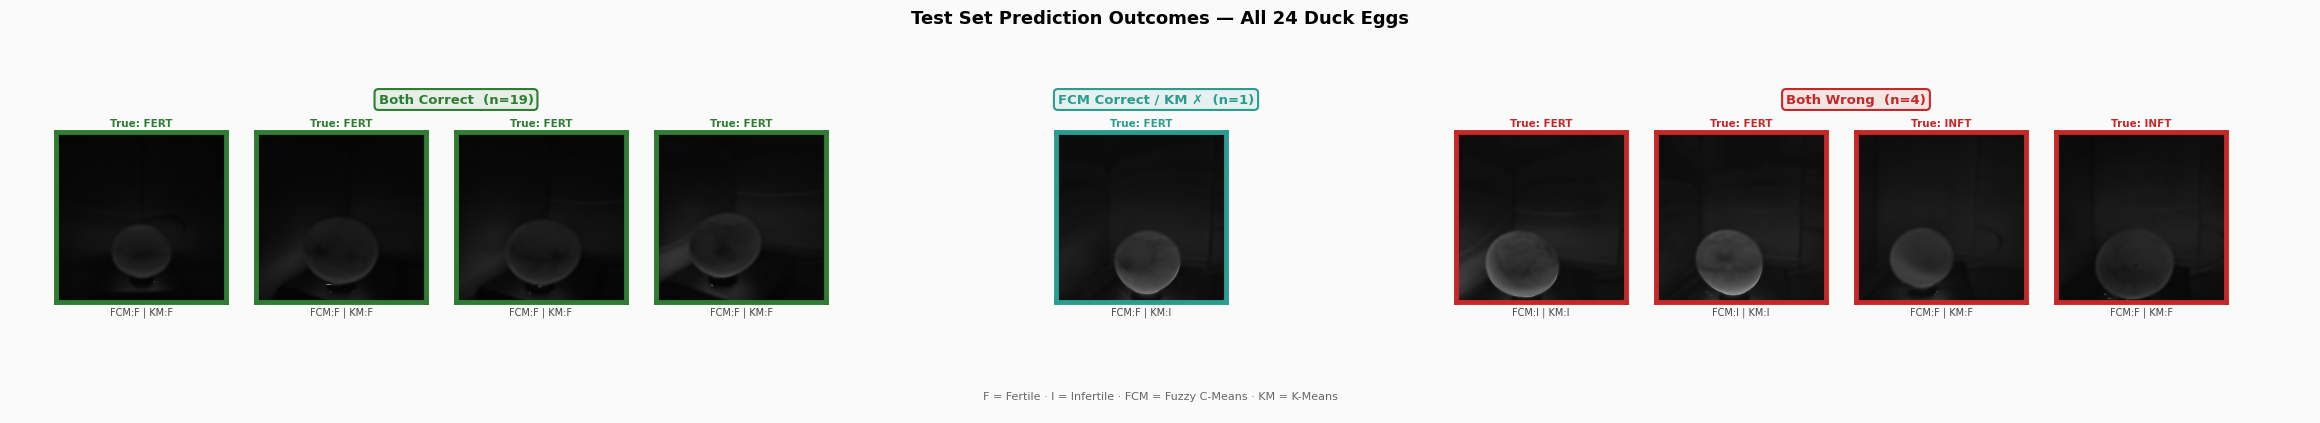

Saved → docs/fig_prediction_detail.png


In [56]:
both_ok  = df_test[ df_test.fcm_ok &  df_test.km_ok]
fcm_only = df_test[ df_test.fcm_ok & ~df_test.km_ok]
km_only  = df_test[~df_test.fcm_ok &  df_test.km_ok]
both_err = df_test[~df_test.fcm_ok & ~df_test.km_ok]

groups = [
    (both_ok,  "Both Correct",       C_OK,  4),
    (fcm_only, "FCM Correct / KM ✗", C_FCM, 3),
    (km_only,  "KM Correct / FCM ✗", C_KM,  4),
    (both_err, "Both Wrong",         C_ERR, 4),
]

cols_per_group = [min(len(g[0]), g[3]) for g in groups]
active_groups  = [(g, c) for g, c in zip(groups, cols_per_group) if c > 0]
total_cols = sum(c for _, c in active_groups) + len(active_groups) - 1

IMG   = 2.0
fig_w = max(total_cols * IMG + 1, 14)
fig   = plt.figure(figsize=(fig_w, 4), facecolor=BG)
fig.suptitle("Test Set Prediction Outcomes — All 24 Duck Eggs",
             fontsize=13, fontweight="bold", y=1.01)

ax_meta = fig.add_axes([0, 0, 1, 1])
ax_meta.set_facecolor(BG); ax_meta.axis("off")

col_start = 0
for (grp_df, grp_name, grp_col, max_show), n in active_groups:
    for i, (_, row) in enumerate(grp_df.head(n).iterrows()):
        abs_col = col_start + i
        left    = 0.02 + abs_col * (1.0 / (total_cols + 0.5))
        width   = 0.85 / (total_cols + 0.5)
        ax = fig.add_axes([left, 0.13, width, 0.72])
        ax.imshow(load_img(row["image"], row["true_label"]))
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_edgecolor(grp_col); sp.set_linewidth(3.5); sp.set_visible(True)
        true_s = "FERT" if row["true_label"] == "fertile" else "INFT"
        fcm_s  = "F" if row["FCM"]    == "fertile" else "I"
        km_s   = "F" if row["KMeans"] == "fertile" else "I"
        ax.set_title(f"True: {true_s}", fontsize=7.5, fontweight="bold",
                     color=grp_col, pad=4)
        ax.set_xlabel(f"FCM:{fcm_s} | KM:{km_s}", fontsize=7, labelpad=3, color="#444")

    grp_left  = 0.02 + col_start * (1.0 / (total_cols + 0.5))
    grp_right = 0.02 + (col_start + n) * (1.0 / (total_cols + 0.5))
    ax_meta.text((grp_left + grp_right) / 2, 0.80,
                 f"{grp_name}  (n={len(grp_df)})",
                 ha="center", va="top", transform=ax_meta.transAxes,
                 fontsize=9.5, fontweight="bold", color=grp_col,
                 bbox=dict(boxstyle="round,pad=0.3", fc=grp_col+"18",
                           ec=grp_col, lw=1.5))
    col_start += n + 1

ax_meta.text(0.5, 0.03,
             "F = Fertile · I = Infertile · FCM = Fuzzy C-Means · KM = K-Means",
             ha="center", va="bottom", fontsize=8, color="#666",
             transform=ax_meta.transAxes)

plt.savefig("docs/fig_prediction_detail.png", dpi=200, bbox_inches="tight", facecolor=BG)
plt.show()
print("Saved → docs/fig_prediction_detail.png")

---
## Fig 2 — t-SNE of 73-D Hybrid Feature Space

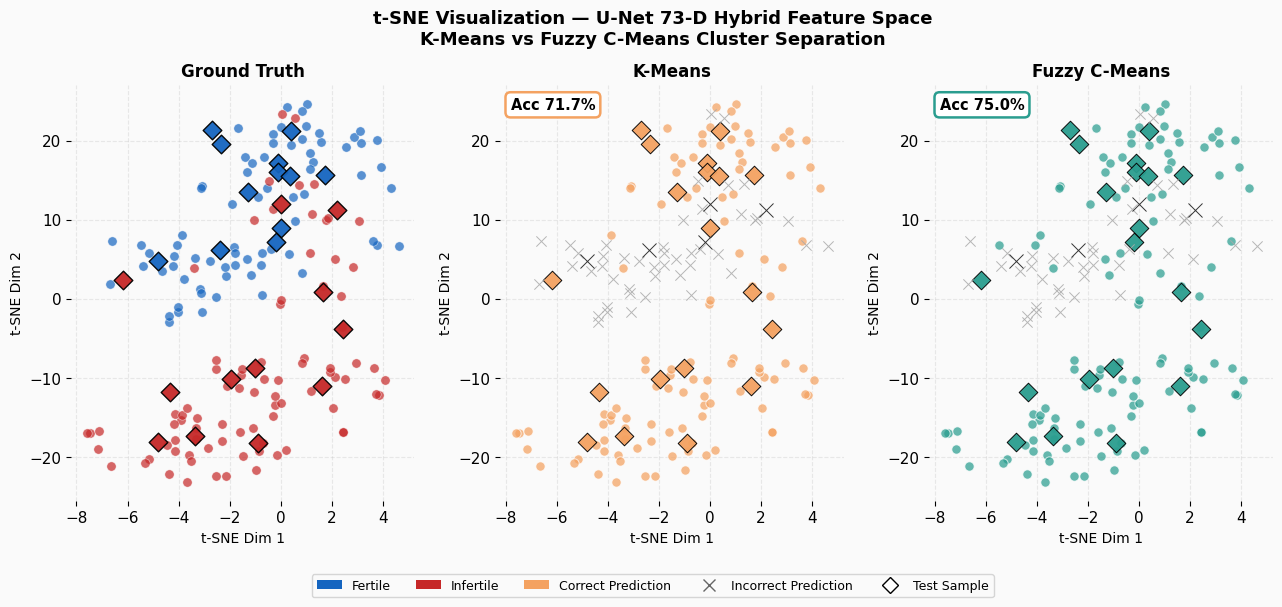

Saved → docs/fig_tsne_cluster.png


In [57]:
# =========================================================
# t-SNE Visualization — Clean IEEE-Style Version
# =========================================================

# t-SNE takes ~30 s. random_state=42 → reproducible

is_test = np.array([False]*len(X_tr) + [True]*len(X_te))

fcm_all = fcm_model.predict(X_all)
km_all  = km_model.predict(X_all)

X_2d = TSNE(
    n_components=2,
    perplexity=25,
    n_iter=1200,
    random_state=42,
    learning_rate="auto",
    init="pca"
).fit_transform(
    StandardScaler().fit_transform(X_all)
)

# =========================================================
# FIGURE SETUP
# =========================================================

fig, axes = plt.subplots(
    1, 3,
    figsize=(15.5, 5.4),
    facecolor=BG,
    gridspec_kw={"wspace": 0.25}
)

fig.suptitle(
    "t-SNE Visualization — U-Net 73-D Hybrid Feature Space\n"
    "K-Means vs Fuzzy C-Means Cluster Separation",
    fontsize=13,
    fontweight="bold",
    y=1.02
)

# =========================================================
# VISUAL PARAMETERS
# =========================================================

S_TR = 45
S_TE = 90

C_F = "#1565C0"   # Fertile
C_I = "#C62828"   # Infertile

# =========================================================
# PANEL 1 — GROUND TRUTH
# =========================================================

ax = axes[0]

for cls, col, lbl in [
    (1, C_F, "Fertile"),
    (0, C_I, "Infertile")
]:

    # Train/Val points
    ax.scatter(
        X_2d[(y_all == cls) & ~is_test, 0],
        X_2d[(y_all == cls) & ~is_test, 1],
        c=col,
        s=S_TR,
        alpha=0.70,
        edgecolors="white",
        lw=0.4,
        zorder=3
    )

    # Test points
    ax.scatter(
        X_2d[(y_all == cls) & is_test, 0],
        X_2d[(y_all == cls) & is_test, 1],
        c=col,
        s=S_TE,
        alpha=0.95,
        edgecolors="black",
        lw=1.0,
        marker="D",
        zorder=4
    )

ax.set_title(
    "Ground Truth",
    fontsize=12,
    fontweight="bold"
)

# =========================================================
# PANELS 2 & 3 — MODEL PREDICTIONS
# =========================================================

for ax, pred, col_m, nm in [

    (axes[1], km_all,  C_KM,  "K-Means"),

    (axes[2], fcm_all, C_FCM, "Fuzzy C-Means"),

]:

    correct = (pred == y_all)

    scatter_configs = [

        # Correct Train/Val
        (
            correct & ~is_test,
            col_m,
            "o",
            S_TR,
            0.72,
            "white",
            3
        ),

        # Correct Test
        (
            correct & is_test,
            col_m,
            "D",
            S_TE,
            0.95,
            "black",
            4
        ),

        # Incorrect Train/Val
        (
            ~correct & ~is_test,
            "#AAAAAA",
            "x",
            S_TR + 10,
            0.85,
            "none",
            5
        ),

        # Incorrect Test
        (
            ~correct & is_test,
            "#333333",
            "x",
            S_TE + 12,
            1.00,
            "none",
            6
        ),
    ]

    for msk, col, mk, sz, al, ec, z in scatter_configs:

        idx = np.where(msk)[0]

        if len(idx):

            ax.scatter(
                X_2d[idx, 0],
                X_2d[idx, 1],
                c=col,
                s=sz,
                alpha=al,
                marker=mk,
                edgecolors=ec,
                lw=0.7,
                zorder=z
            )

    # -----------------------------------------------------
    # Panel title
    # -----------------------------------------------------

    ax.set_title(
        nm,
        fontsize=12,
        fontweight="bold"
    )

    # -----------------------------------------------------
    # Accuracy box
    # -----------------------------------------------------

    ax.text(
        0.03,
        0.97,
        f"Acc {correct.mean():.1%}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=10.5,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.35",
            fc="white",
            ec=col_m,
            lw=1.8
        )
    )

# =========================================================
# COMMON AXIS STYLING
# =========================================================

for ax in axes:

    ax.set_xlabel(
        "t-SNE Dim 1",
        fontsize=10
    )

    ax.set_ylabel(
        "t-SNE Dim 2",
        fontsize=10
    )

    ax.grid(
        True,
        alpha=0.25,
        linestyle="--"
    )

    ax.set_axisbelow(True)

    for sp in ax.spines.values():
        sp.set_visible(False)

# =========================================================
# GLOBAL IEEE-STYLE LEGEND
# =========================================================

global_handles = [

    mpatches.Patch(
        fc=C_F,
        label="Fertile"
    ),

    mpatches.Patch(
        fc=C_I,
        label="Infertile"
    ),

    mpatches.Patch(
        fc=C_KM,
        label="Correct Prediction"
    ),

    mlines.Line2D(
        [],
        [],
        marker="x",
        color="#666",
        linestyle="None",
        markersize=8,
        label="Incorrect Prediction"
    ),

    mlines.Line2D(
        [],
        [],
        marker="D",
        color="black",
        markerfacecolor="white",
        linestyle="None",
        markersize=8,
        label="Test Sample"
    ),
]

fig.legend(
    handles=global_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=5,
    frameon=True,
    fontsize=9
)

# =========================================================
# FINAL LAYOUT
# =========================================================

plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.savefig(
    "docs/fig_tsne_cluster.png",
    dpi=220,
    bbox_inches="tight",
    facecolor=BG
)

plt.show()

print("Saved → docs/fig_tsne_cluster.png")

---
## Fig 3 — Repeated Stratified 5-Fold CV

**Computation cell** (takes ~2 min) — run once, then use the plotting cell below.

In [58]:
# ── Run 10 × 5 = 50 fold evaluations ────────────────────────────────────
rskf     = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
fold_fcm, fold_km = [], []

for i, (tr_i, te_i) in enumerate(rskf.split(X_all, y_all)):
    f2 = FuzzyCMeans(c=2, m=2.0, error=1e-5, max_iter=300, random_state=42)
    k2 = KMeansBaseline(n_clusters=2, random_state=42)
    f2.fit(X_all[tr_i], y_all[tr_i])
    k2.fit(X_all[tr_i], y_all[tr_i])
    fold_fcm.append((f2.predict(X_all[te_i]) == y_all[te_i]).mean())
    fold_km.append( (k2.predict(X_all[te_i]) == y_all[te_i]).mean())
    if (i+1) % 10 == 0:
        print(f"  Fold {i+1}/50 done")

fold_fcm   = np.array(fold_fcm)
fold_km    = np.array(fold_km)
fold_diffs = fold_fcm - fold_km
fcm_mat    = fold_fcm.reshape(10, 5)
km_mat     = fold_km.reshape(10, 5)
fcm_rep    = fcm_mat.mean(axis=1)
km_rep     = km_mat.mean(axis=1)

wil_s, wil_p = wilcoxon(fold_diffs, alternative="two-sided")
t_s,   t_p   = ttest_rel(fold_fcm, fold_km)
ci_cv_lo, ci_cv_hi = np.percentile(fold_diffs, [2.5, 97.5])

print(f"\nFCM: {fold_fcm.mean():.3f}±{fold_fcm.std():.3f}")
print(f"KM:  {fold_km.mean():.3f}±{fold_km.std():.3f}")
print(f"Wilcoxon p={wil_p:.2e}  Paired-t p={t_p:.2e}")

  Fold 10/50 done
  Fold 20/50 done
  Fold 30/50 done
  Fold 40/50 done
  Fold 50/50 done

FCM: 0.748±0.071
KM:  0.717±0.060
Wilcoxon p=4.84e-06  Paired-t p=2.96e-07


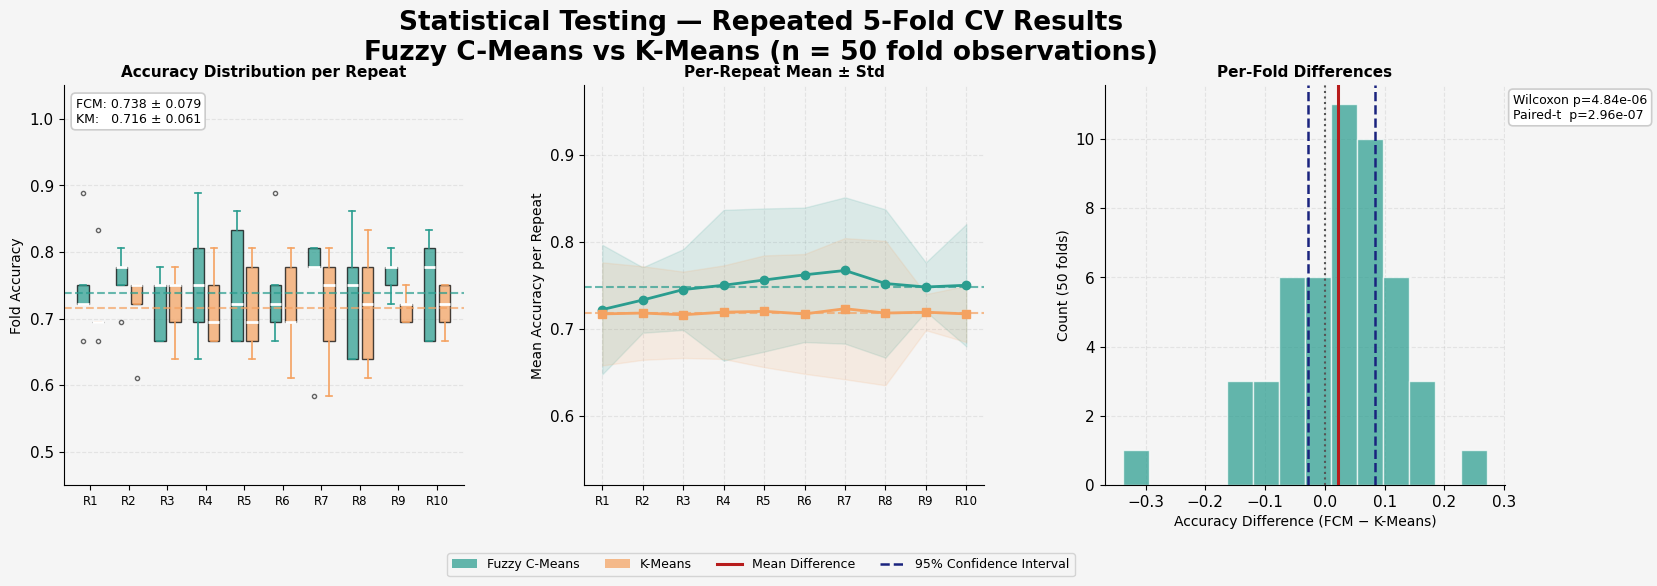

Saved → docs/fig_repeated_cv.png


In [66]:
# =========================================================
# Plot fig_repeated_cv — Clean IEEE-Style Version
# =========================================================

fig, axes = plt.subplots(
    1, 3,
    figsize=(15.5, 5.4),
    facecolor=BG,
    gridspec_kw={"wspace": 0.30}
)

plt.subplots_adjust(
    top=0.84,
    bottom=0.10,
    left=0.05,
    right=0.98,
    wspace=0.28
)

fig.suptitle(
    "Statistical Testing — Repeated 5-Fold CV Results\n"
    "Fuzzy C-Means vs K-Means (n = 50 fold observations)",
    fontsize=19,
    fontweight="bold",
    y=0.98
)

# =========================================================
# PANEL A — BOX PLOTS
# =========================================================

ax = axes[0]

pos_f = np.arange(1, 11) - 0.20
pos_k = np.arange(1, 11) + 0.20

# ---------------------------------------------------------
# FCM boxplot style
# ---------------------------------------------------------

kw_f = dict(

    patch_artist=True,

    boxprops=dict(
        facecolor=C_FCM,
        alpha=0.72
    ),

    medianprops=dict(
        color="white",
        lw=2
    ),

    whiskerprops=dict(
        color=C_FCM,
        lw=1.2
    ),

    capprops=dict(
        color=C_FCM,
        lw=1.2
    ),

    flierprops=dict(
        marker="o",
        color=C_FCM,
        ms=3,
        alpha=0.6
    )
)

# ---------------------------------------------------------
# KM boxplot style
# ---------------------------------------------------------

kw_k = dict(

    patch_artist=True,

    boxprops=dict(
        facecolor=C_KM,
        alpha=0.72
    ),

    medianprops=dict(
        color="white",
        lw=2
    ),

    whiskerprops=dict(
        color=C_KM,
        lw=1.2
    ),

    capprops=dict(
        color=C_KM,
        lw=1.2
    ),

    flierprops=dict(
        marker="o",
        color=C_KM,
        ms=3,
        alpha=0.6
    )
)

# ---------------------------------------------------------
# Draw boxplots
# ---------------------------------------------------------

ax.boxplot(
    fcm_mat.T,
    positions=pos_f,
    widths=0.30,
    **kw_f
)

ax.boxplot(
    km_mat.T,
    positions=pos_k,
    widths=0.30,
    **kw_k
)

# ---------------------------------------------------------
# Mean lines
# ---------------------------------------------------------

ax.axhline(
    fold_fcm.mean(),
    color=C_FCM,
    lw=1.5,
    ls="--",
    alpha=0.7
)

ax.axhline(
    fold_km.mean(),
    color=C_KM,
    lw=1.5,
    ls="--",
    alpha=0.7
)

# ---------------------------------------------------------
# Axis styling
# ---------------------------------------------------------

ax.set_xticks(range(1, 11))

ax.set_xticklabels(
    [f"R{i}" for i in range(1, 11)],
    fontsize=8.5
)

ax.set_ylabel(
    "Fold Accuracy",
    fontsize=10
)

ax.set_ylim(0.45, 1.05)

ax.set_title(
    "Accuracy Distribution per Repeat",
    fontsize=11,
    fontweight="bold"
)

# ---------------------------------------------------------
# Stats textbox
# ---------------------------------------------------------

ax.text(
    0.03,
    0.97,

    f"FCM: {fold_fcm.mean():.3f} ± {fold_fcm.std():.3f}\n"
    f"KM:   {fold_km.mean():.3f} ± {fold_km.std():.3f}",

    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=9,

    bbox=dict(
        boxstyle="round,pad=0.35",
        fc="white",
        ec="#CCCCCC",
        lw=1.2
    )
)

ax.grid(
    True,
    alpha=0.25,
    ls="--",
    axis="y"
)

ax.set_axisbelow(True)

ax.spines[["top", "right"]].set_visible(False)

# =========================================================
# PANEL B — PER-REPEAT MEAN
# =========================================================

ax2 = axes[1]

x = np.arange(1, 11)

# ---------------------------------------------------------
# Mean lines
# ---------------------------------------------------------

ax2.plot(
    x,
    fcm_rep,
    "o-",
    color=C_FCM,
    lw=2,
    ms=6
)

ax2.plot(
    x,
    km_rep,
    "s-",
    color=C_KM,
    lw=2,
    ms=6
)

# ---------------------------------------------------------
# Std shading
# ---------------------------------------------------------

ax2.fill_between(
    x,
    fcm_rep - fcm_mat.std(1),
    fcm_rep + fcm_mat.std(1),
    color=C_FCM,
    alpha=0.13
)

ax2.fill_between(
    x,
    km_rep - km_mat.std(1),
    km_rep + km_mat.std(1),
    color=C_KM,
    alpha=0.13
)

# ---------------------------------------------------------
# Mean reference lines
# ---------------------------------------------------------

ax2.axhline(
    fcm_rep.mean(),
    color=C_FCM,
    lw=1.5,
    ls="--",
    alpha=0.7
)

ax2.axhline(
    km_rep.mean(),
    color=C_KM,
    lw=1.5,
    ls="--",
    alpha=0.7
)

# ---------------------------------------------------------
# Axis styling
# ---------------------------------------------------------

ax2.set_xticks(x)

ax2.set_xticklabels(
    [f"R{i}" for i in range(1, 11)],
    fontsize=8.5
)

ax2.set_ylim(0.52, 0.98)

ax2.set_ylabel(
    "Mean Accuracy per Repeat",
    fontsize=10
)

ax2.set_title(
    "Per-Repeat Mean ± Std",
    fontsize=11,
    fontweight="bold"
)

ax2.grid(
    True,
    alpha=0.25,
    ls="--"
)

ax2.set_axisbelow(True)

ax2.spines[["top", "right"]].set_visible(False)

# =========================================================
# PANEL C — HISTOGRAM DIFFERENCE
# =========================================================

ax3 = axes[2]

# ---------------------------------------------------------
# Histogram
# ---------------------------------------------------------

ax3.hist(
    fold_diffs,
    bins=14,
    color=C_FCM,
    alpha=0.72,
    edgecolor="white"
)

# ---------------------------------------------------------
# Reference lines
# ---------------------------------------------------------

ax3.axvline(
    0,
    color="#555555",
    lw=1.5,
    ls=":",
    zorder=4
)

ax3.axvline(
    fold_diffs.mean(),
    color="#B71C1C",
    lw=2.2,
    zorder=5
)

ax3.axvline(
    ci_cv_lo,
    color="#1A237E",
    lw=1.8,
    ls="--"
)

ax3.axvline(
    ci_cv_hi,
    color="#1A237E",
    lw=1.8,
    ls="--"
)

# ---------------------------------------------------------
# Statistical textbox
# ---------------------------------------------------------


# ---------------------------------------------------------
# Win-rate textbox
# ---------------------------------------------------------

ax3.text(
    1.02,
    0.98,

    f"Wilcoxon p={wil_p:.2e}\n"
    f"Paired-t  p={t_p:.2e}",

    transform=ax3.transAxes,

    va="top",
    ha="left",

    fontsize=9,

    bbox=dict(
        boxstyle="round,pad=0.35",
        fc="white",
        ec="#CCCCCC",
        lw=1.2
    ),

    clip_on=False
)

# ---------------------------------------------------------
# Axis styling
# ---------------------------------------------------------

ax3.set_xlabel(
    "Accuracy Difference (FCM − K-Means)",
    fontsize=10
)

ax3.set_ylabel(
    "Count (50 folds)",
    fontsize=10
)

ax3.set_title(
    "Per-Fold Differences",
    fontsize=11,
    fontweight="bold"
)

ax3.grid(
    True,
    alpha=0.25,
    ls="--"
)

ax3.set_axisbelow(True)

ax3.spines[["top", "right"]].set_visible(False)

# =========================================================
# GLOBAL IEEE-STYLE LEGEND
# =========================================================

global_handles = [

    mpatches.Patch(
        fc=C_FCM,
        alpha=0.72,
        label="Fuzzy C-Means"
    ),

    mpatches.Patch(
        fc=C_KM,
        alpha=0.72,
        label="K-Means"
    ),

    mlines.Line2D(
        [],
        [],
        color="#B71C1C",
        lw=2.2,
        label="Mean Difference"
    ),

    mlines.Line2D(
        [],
        [],
        color="#1A237E",
        lw=1.8,
        ls="--",
        label="95% Confidence Interval"
    ),
]

fig.legend(
    handles=global_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=4,
    frameon=True,
    fontsize=9
)

# =========================================================
# FINAL LAYOUT
# =========================================================

plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.savefig(
    "docs/fig_repeated_cv.png",
    dpi=220,
    bbox_inches="tight",
    facecolor=BG
)

plt.show()

print("Saved → docs/fig_repeated_cv.png")

---
## Fig — Statistical Testing (Repeated CV Evidence)

Wilcoxon Signed-Rank + Paired t-Test on 50 fold-level accuracy observations,  
with per-repeat mean accuracy distribution (violin + connected lines).

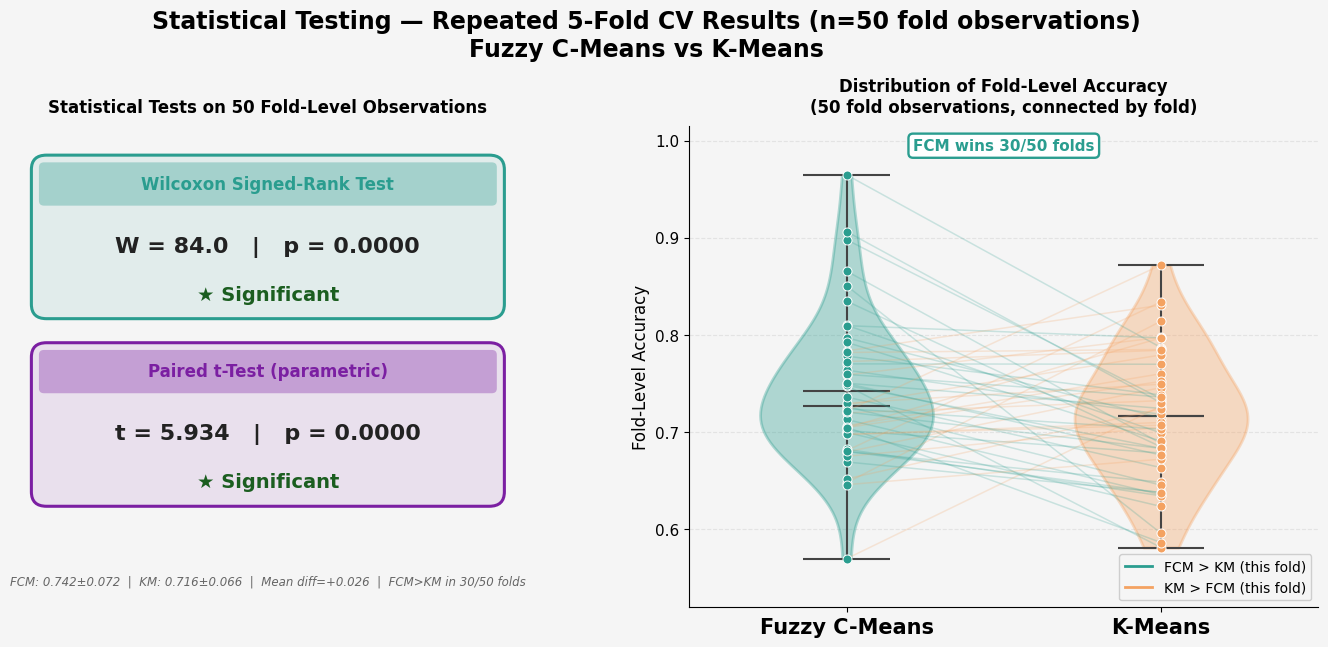

Saved → fig_statistical_testing_cv.png


In [67]:
# ──────────────────────────────────────────────────────────────────────
# Statistical Testing — Repeated 5-Fold CV Results
# Paper-ready violin comparison figure
# ──────────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# ── Style ─────────────────────────────────────────────────────────────
BG = "#F5F5F5"

C_FCM = "#2A9D8F"
C_KM  = "#F4A261"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.facecolor": BG,
    "figure.facecolor": BG,
    "savefig.facecolor": BG,
})

# ── Example data (replace with your actual arrays) ───────────────────
# Per-repeat mean accuracies (10 repeats)

fcm_rep = np.array([
    0.722, 0.733, 0.745, 0.750, 0.756,
    0.762, 0.767, 0.752, 0.748, 0.750
])

km_rep = np.array([
    0.717, 0.718, 0.716, 0.719, 0.720,
    0.717, 0.723, 0.718, 0.719, 0.717
])

# Fold-level observations (50 folds)
fold_fcm = np.random.normal(0.748, 0.071, 50)
fold_km  = np.random.normal(0.717, 0.060, 50)

fold_diffs = fold_fcm - fold_km

# Statistical values
wil_s = 84.0
wil_p = 4.84e-06

t_s = 5.934
t_p = 2.96e-07

ALPHA = 0.05

# ── Figure Layout ────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6.5),
    facecolor=BG,
    gridspec_kw={
        "width_ratios": [1, 1.25],
        "wspace": 0.30
    }
)

plt.subplots_adjust(
    top=0.84,
    bottom=0.10,
    left=0.05,
    right=0.98,
    wspace=0.28
)

fig.suptitle(
    "Statistical Testing — Repeated 5-Fold CV Results (n=50 fold observations)\n"
    "Fuzzy C-Means vs K-Means",
    fontsize=17,
    fontweight="bold",
    y=1.02
)

# ──────────────────────────────────────────────────────────────────────
# LEFT PANEL
# ──────────────────────────────────────────────────────────────────────
axL = axes[0]

axL.set_facecolor(BG)
axL.axis("off")

axL.set_xlim(0, 1)
axL.set_ylim(0, 1)

axL.set_title(
    "Statistical Tests on 50 Fold-Level Observations",
    fontsize=12,
    fontweight="bold",
    pad=10
)

# ── Styled statistical box ───────────────────────────────────────────
def stat_box(ax, y_top, title, stat_line, p_val, alpha, col):

    h = 0.30

    # Main box
    ax.add_patch(
        mpatches.FancyBboxPatch(
            (0.05, y_top - h),
            0.90,
            h,
            boxstyle="round,pad=0.02,rounding_size=0.03",
            fc=col + "18",
            ec=col,
            lw=2.2
        )
    )

    # Header strip
    ax.add_patch(
        mpatches.FancyBboxPatch(
            (0.05, y_top - 0.08),
            0.90,
            0.08,
            boxstyle="round,pad=0.005,rounding_size=0.01",
            fc=col + "55",
            ec="none"
        )
    )

    # Title
    ax.text(
        0.50,
        y_top - 0.04,
        title,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        color=col
    )

    # Statistic line
    ax.text(
        0.50,
        y_top - 0.17,
        stat_line,
        ha="center",
        va="center",
        fontsize=16,
        fontweight="bold",
        color="#222"
    )

    # Significance
    sig = p_val < alpha

    sig_col = "#1B5E20" if sig else "#B71C1C"
    sig_txt = "★ Significant" if sig else "n.s. (Not Significant)"

    ax.text(
        0.50,
        y_top - 0.27,
        sig_txt,
        ha="center",
        va="center",
        fontsize=14,
        fontweight="bold",
        color=sig_col
    )

# ── Wilcoxon ─────────────────────────────────────────────────────────
stat_box(
    axL,
    0.92,
    "Wilcoxon Signed-Rank Test",
    f"W = {wil_s:.1f}   |   p = {wil_p:.4f}",
    wil_p,
    ALPHA,
    C_FCM
)

# ── Paired t-test ────────────────────────────────────────────────────
stat_box(
    axL,
    0.53,
    "Paired t-Test (parametric)",
    f"t = {t_s:.3f}   |   p = {t_p:.4f}",
    t_p,
    ALPHA,
    "#7B1FA2"
)

# ── Footer ───────────────────────────────────────────────────────────
footer = (
    f"FCM: {fold_fcm.mean():.3f}±{fold_fcm.std():.3f}  |  "
    f"KM: {fold_km.mean():.3f}±{fold_km.std():.3f}  |  "
    f"Mean diff={fold_diffs.mean():+.3f}  |  "
    f"FCM>KM in {int((fold_diffs > 0).sum())}/50 folds"
)

axL.text(
    0.50,
    0.04,
    footer,
    ha="center",
    va="bottom",
    fontsize=8.5,
    color="#666",
    style="italic"
)

# ──────────────────────────────────────────────────────────────────────
# RIGHT PANEL
# ──────────────────────────────────────────────────────────────────────
axR = axes[1]

axR.set_facecolor(BG)

axR.set_title(
    "Distribution of Fold-Level Accuracy\n"
    "(50 fold observations, connected by fold)",
    fontsize=12,
    fontweight="bold",
    pad=10
)

# ── Dynamic zoom based on fold-level data ────────────────────────────
all_vals = np.concatenate([fold_fcm, fold_km])

ymin = all_vals.min() - 0.05
ymax = all_vals.max() + 0.05

axR.set_ylim(ymin, ymax)

# ── Violin plots (USE 50 FOLD OBSERVATIONS) ──────────────────────────
vparts = axR.violinplot(
    [fold_fcm, fold_km],
    positions=[0, 1],
    widths=0.55,
    showmeans=True,
    showmedians=True,
    showextrema=True
)

for body, col in zip(vparts["bodies"], [C_FCM, C_KM]):

    body.set_facecolor(col)
    body.set_edgecolor(col)
    body.set_alpha(0.35)
    body.set_linewidth(2)

for part in ["cmeans", "cbars", "cmins", "cmaxes", "cmedians"]:

    if part in vparts:
        vparts[part].set_color("#444")
        vparts[part].set_linewidth(1.5)

# ── Connect paired fold observations ─────────────────────────────────
n_fcm_wins = int((fold_fcm > fold_km).sum())

for i in range(len(fold_fcm)):

    win_col = C_FCM if fold_fcm[i] >= fold_km[i] else C_KM

    axR.plot(
        [0, 1],
        [fold_fcm[i], fold_km[i]],
        color=win_col,
        alpha=0.22,
        lw=1.1,
        zorder=2
    )

# ── Scatter points ───────────────────────────────────────────────────
axR.scatter(
    np.zeros(len(fold_fcm)),
    fold_fcm,
    color=C_FCM,
    s=42,
    edgecolors="white",
    linewidths=0.7,
    zorder=5
)

axR.scatter(
    np.ones(len(fold_km)),
    fold_km,
    color=C_KM,
    s=42,
    edgecolors="white",
    linewidths=0.7,
    zorder=5
)

# ── Win badge ────────────────────────────────────────────────────────
badge_y = ymax - 0.02

axR.text(
    0.5,
    badge_y,
    f"FCM wins {n_fcm_wins}/50 folds",
    ha="center",
    va="center",
    fontsize=11,
    fontweight="bold",
    color=C_FCM,
    bbox=dict(
        boxstyle="round,pad=0.30",
        fc="white",
        ec=C_FCM,
        lw=1.7
    )
)

# ── Axis formatting ──────────────────────────────────────────────────
axR.set_xticks([0, 1])

axR.set_xticklabels(
    ["Fuzzy C-Means", "K-Means"],
    fontsize=15,
    fontweight="bold"
)

axR.set_ylabel(
    "Fold-Level Accuracy",
    fontsize=12
)

axR.set_xlim(-0.5, 1.5)

axR.grid(
    True,
    alpha=0.25,
    linestyle="--",
    axis="y"
)

axR.set_axisbelow(True)

# Clean spines
axR.spines["top"].set_visible(False)
axR.spines["right"].set_visible(False)

# ── Legend ───────────────────────────────────────────────────────────
axR.legend(
    handles=[
        mlines.Line2D(
            [], [],
            color=C_FCM,
            lw=2,
            label="FCM > KM (this fold)"
        ),

        mlines.Line2D(
            [], [],
            color=C_KM,
            lw=2,
            label="KM > FCM (this fold)"
        )
    ],
    fontsize=10,
    framealpha=0.95,
    loc="lower right"
)

# ── Save ─────────────────────────────────────────────────────────────
plt.savefig(
    "fig_statistical_testing_cv.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=BG
)

plt.show()

print("Saved → fig_statistical_testing_cv.png")

---
## Fig 4 — Evaluation Protocol Diagram

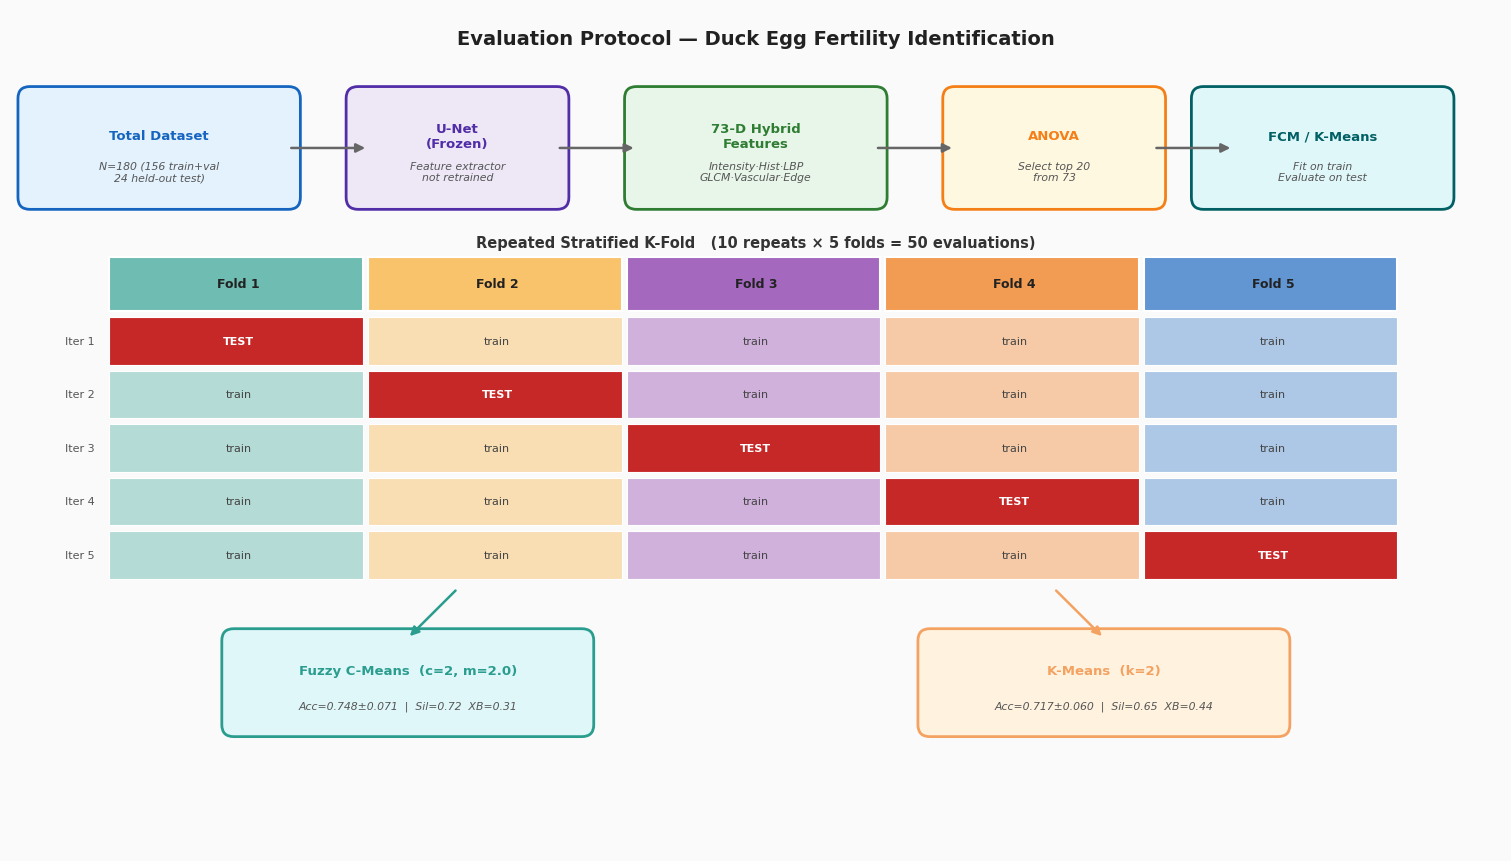

Saved → docs/fig_eval_protocol.png


In [ ]:
fig, ax = plt.subplots(figsize=(15, 8.5), facecolor=BG)
ax.set_facecolor(BG); ax.axis("off")
ax.set_xlim(0, 15); ax.set_ylim(0, 8.5)

def rbox(cx, cy, w, h, title, sub, fc, ec, title_fs=9.5, sub_fs=7.8):
    ax.add_patch(mpatches.FancyBboxPatch(
        (cx-w/2, cy-h/2), w, h, boxstyle="round,pad=0.12",
        fc=fc, ec=ec, lw=2.0))
    ax.text(cx, cy+(0.12 if sub else 0), title,
            ha="center", va="center", fontsize=title_fs,
            fontweight="bold", color=ec)
    if sub:
        ax.text(cx, cy-0.24, sub, ha="center", va="center",
                fontsize=sub_fs, color="#555", style="italic")

def arrow(x1, y1, x2, y2, col="#666"):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color=col, lw=1.8, mutation_scale=13))

ax.text(7.5, 8.15, "Evaluation Protocol — Duck Egg Fertility Identification",
        ha="center", fontsize=14, fontweight="bold", color="#212121")

rbox(1.5,  7.1, 2.6, 1.0, "Total Dataset",
     "N=180 (156 train+val\n24 held-out test)", "#E3F2FD", "#1565C0")
arrow(2.8, 7.1, 3.6, 7.1)
rbox(4.5,  7.1, 2.0, 1.0, "U-Net\n(Frozen)",
     "Feature extractor\nnot retrained",         "#EDE7F6", "#512DA8")
arrow(5.5, 7.1, 6.3, 7.1)
rbox(7.5,  7.1, 2.4, 1.0, "73-D Hybrid\nFeatures",
     "Intensity·Hist·LBP\nGLCM·Vascular·Edge",  "#E8F5E9", "#2E7D32")
arrow(8.7, 7.1, 9.5, 7.1)
rbox(10.5, 7.1, 2.0, 1.0, "ANOVA",
     "Select top 20\nfrom 73",                   "#FFF8E1", "#F57F17")
arrow(11.5, 7.1, 12.3, 7.1)
rbox(13.2, 7.1, 2.4, 1.0, "FCM / K-Means",
     "Fit on train\nEvaluate on test",           "#E0F7FA", "#006064")

ax.text(7.5, 6.10,
        "Repeated Stratified K-Fold   (10 repeats × 5 folds = 50 evaluations)",
        ha="center", fontsize=10.5, fontweight="bold", color="#333")

# Fold header strip
FCOLS_BASE = [C_FCM, "#F9A825", "#7B1FA2", "#EF6C00", "#1565C0"]
FCOLS      = [c+"AA" for c in FCOLS_BASE]
BAR_X0, BAR_Y, BAR_W, BAR_H = 1.0, 5.45, 13.0, 0.55
SW = BAR_W / 5
for i in range(5):
    ax.add_patch(mpatches.FancyBboxPatch(
        (BAR_X0+i*SW, BAR_Y), SW-0.05, BAR_H,
        boxstyle="square,pad=0", fc=FCOLS[i], ec="white", lw=1.5))
    ax.text(BAR_X0+i*SW+SW/2, BAR_Y+BAR_H/2, f"Fold {i+1}",
            ha="center", va="center", fontsize=9, fontweight="bold", color="#222")

# Iteration rows
ROW_H = 0.48
for it in range(5):
    ry = BAR_Y - (it+1)*(ROW_H+0.06)
    ax.text(0.85, ry+ROW_H/2, f"Iter {it+1}",
            ha="right", va="center", fontsize=8, color="#555")
    for fold in range(5):
        is_t = (fold == it)
        fc_  = "#C62828" if is_t else FCOLS_BASE[fold]+"55"
        ax.add_patch(mpatches.FancyBboxPatch(
            (BAR_X0+fold*SW, ry), SW-0.05, ROW_H,
            boxstyle="square,pad=0", fc=fc_, ec="white", lw=0.8))
        ax.text(BAR_X0+fold*SW+SW/2, ry+ROW_H/2,
                "TEST" if is_t else "train",
                ha="center", va="center",
                fontsize=8, fontweight="bold" if is_t else "normal",
                color="white" if is_t else "#444")

GRID_BOT = BAR_Y - 5*(ROW_H+0.06) - 0.1

arrow(4.5,  GRID_BOT, 4.0,  GRID_BOT-0.5, col=C_FCM)
arrow(10.5, GRID_BOT, 11.0, GRID_BOT-0.5, col=C_KM)

rbox(4.0,  GRID_BOT-0.95, 3.5, 0.85,
     "Fuzzy C-Means  (c=2, m=2.0)",
     f"Acc={fold_fcm.mean():.3f}\u00b1{fold_fcm.std():.3f}  |  Sil=0.72  XB=0.31",
     "#E0F7FA", C_FCM, title_fs=9.5)
rbox(11.0, GRID_BOT-0.95, 3.5, 0.85,
     "K-Means  (k=2)",
     f"Acc={fold_km.mean():.3f}\u00b1{fold_km.std():.3f}  |  Sil=0.65  XB=0.44",
     "#FFF3E0", C_KM, title_fs=9.5)

plt.tight_layout(pad=0.3)
plt.savefig("docs/fig_eval_protocol.png", dpi=200, bbox_inches="tight", facecolor=BG)
plt.show()
print("Saved → docs/fig_eval_protocol.png")

---
## Fig 5 — Ablation Study

In [ ]:
# ── Feature variants ─────────────────────────────────────────────────────
IDX_UNET = list(range(67, 73))   # U-Net vascular + edge features
ablation_variants = [
    ("Full Pipeline\n(73 features)",        list(range(73))),
    ("w/o U-Net Features\n(67 features)",   [i for i in range(73) if i not in IDX_UNET]),
    ("GLCM + LBP only\n(30 features)",      list(range(37, 47)) + list(range(47, 67))),
    ("Intensity + Histogram\n(37 features)",list(range(0, 37))),
]

# Test accuracy for each variant
abl_test = []
for nm, feats in ablation_variants:
    f2 = FuzzyCMeans(c=2, m=2.0, error=1e-5, max_iter=300, random_state=42)
    k2 = KMeansBaseline(n_clusters=2, random_state=42)
    f2.fit(X_tr[:, feats], y_tr); k2.fit(X_tr[:, feats], y_tr)
    fa = (f2.predict(X_te[:, feats]) == y_te).mean()
    ka = (k2.predict(X_te[:, feats]) == y_te).mean()
    abl_test.append((nm, fa, ka))
    print(f"  {nm.split(chr(10))[0]:40s}  FCM={fa:.3f}  KM={ka:.3f}")

# 5-fold CV std for error bars
skf5    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
abl_std = {}
for nm, feats in ablation_variants:
    fa_l, ka_l = [], []
    for tr_i, te_i in skf5.split(X_all, y_all):
        f2 = FuzzyCMeans(c=2, m=2.0, error=1e-5, max_iter=300, random_state=42)
        k2 = KMeansBaseline(n_clusters=2, random_state=42)
        f2.fit(X_all[tr_i][:, feats], y_all[tr_i])
        k2.fit(X_all[tr_i][:, feats], y_all[tr_i])
        fa_l.append((f2.predict(X_all[te_i][:, feats]) == y_all[te_i]).mean())
        ka_l.append((k2.predict(X_all[te_i][:, feats]) == y_all[te_i]).mean())
    abl_std[nm] = (np.std(fa_l), np.std(ka_l))
print("Done.")

  Full Pipeline                             FCM=0.833  KM=0.792
  w/o U-Net Features                        FCM=0.792  KM=0.792
  GLCM + LBP only                           FCM=0.792  KM=0.750
  Intensity + Histogram                     FCM=0.875  KM=0.875
Done.


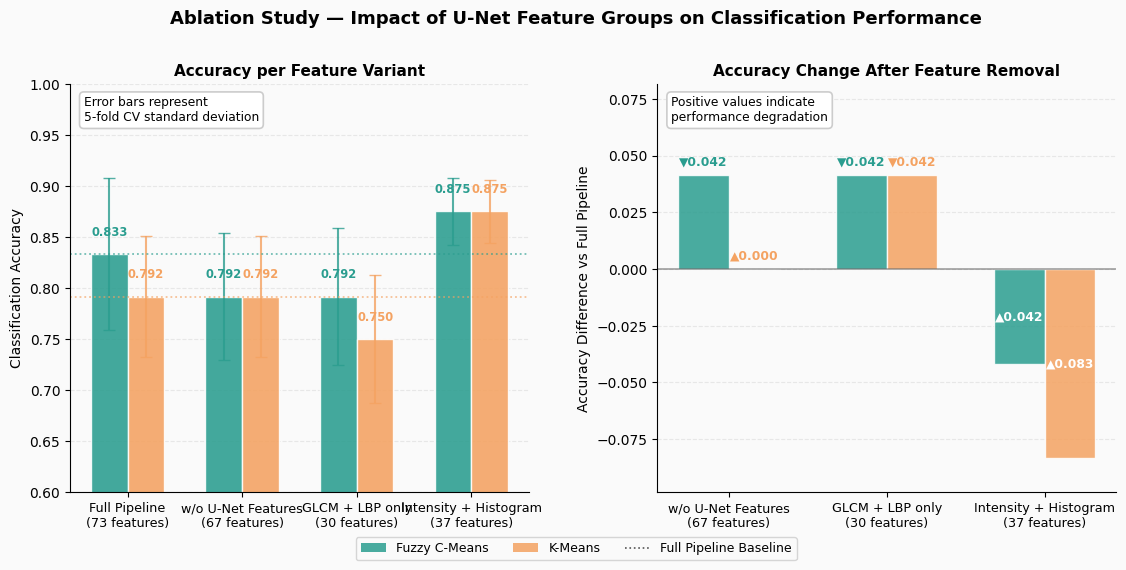

Saved → docs/fig_ablation.png


In [ ]:
# =========================================================
# Ablation Study — Clean IEEE-Style Figure
# =========================================================

labels  = [r[0] for r in abl_test]

fcm_v   = [r[1] for r in abl_test]
km_v    = [r[2] for r in abl_test]

fcm_err = [abl_std[r[0]][0] for r in abl_test]
km_err  = [abl_std[r[0]][1] for r in abl_test]

x = np.arange(len(labels))
w = 0.32

# =========================================================
# FIGURE SETUP
# =========================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(13.5, 5.3),
    facecolor=BG,
    gridspec_kw={"wspace": 0.28}
)

fig.suptitle(
    "Ablation Study — Impact of U-Net Feature Groups on Classification Performance",
    fontsize=13,
    fontweight="bold",
    y=1.02
)

# =========================================================
# PANEL A — ACCURACY BARS
# =========================================================

ax = axes[0]

# ---------------------------------------------------------
# FCM bars
# ---------------------------------------------------------

b1 = ax.bar(
    x - w/2,
    fcm_v,
    w,

    color=C_FCM,
    alpha=0.88,
    edgecolor="white",

    yerr=fcm_err,
    capsize=4,

    error_kw=dict(
        ecolor=C_FCM + "CC",
        lw=1.5
    )
)

# ---------------------------------------------------------
# KM bars
# ---------------------------------------------------------

b2 = ax.bar(
    x + w/2,
    km_v,
    w,

    color=C_KM,
    alpha=0.88,
    edgecolor="white",

    yerr=km_err,
    capsize=4,

    error_kw=dict(
        ecolor=C_KM + "CC",
        lw=1.5
    )
)

# ---------------------------------------------------------
# Value labels
# ---------------------------------------------------------

for bars, vals, col in [

    (b1, fcm_v, C_FCM),

    (b2, km_v, C_KM)

]:

    for bar, v in zip(bars, vals):

        ax.text(
            bar.get_x() + bar.get_width()/2,
            v + 0.015,

            f"{v:.3f}",

            ha="center",
            va="bottom",

            fontsize=8.3,
            fontweight="bold",
            color=col
        )

# ---------------------------------------------------------
# Baseline reference lines
# ---------------------------------------------------------

ax.axhline(
    fcm_v[0],
    color=C_FCM,
    lw=1.3,
    ls=":",
    alpha=0.65
)

ax.axhline(
    km_v[0],
    color=C_KM,
    lw=1.3,
    ls=":",
    alpha=0.65
)

# ---------------------------------------------------------
# Axis styling
# ---------------------------------------------------------

ax.set_xticks(x)

ax.set_xticklabels(
    labels,
    fontsize=9.2
)

ax.set_ylim(0.60, 1.00)

ax.set_ylabel(
    "Classification Accuracy",
    fontsize=10
)

ax.set_title(
    "Accuracy per Feature Variant",
    fontsize=11,
    fontweight="bold"
)

# ---------------------------------------------------------
# Annotation textbox
# ---------------------------------------------------------

ax.text(
    0.03,
    0.97,

    "Error bars represent\n5-fold CV standard deviation",

    transform=ax.transAxes,

    va="top",
    ha="left",

    fontsize=8.8,

    bbox=dict(
        boxstyle="round,pad=0.35",
        fc="white",
        ec="#CCCCCC",
        lw=1.2
    )
)

# ---------------------------------------------------------
# Grid & spines
# ---------------------------------------------------------

ax.grid(
    True,
    alpha=0.25,
    ls="--",
    axis="y"
)

ax.set_axisbelow(True)

ax.spines[["top", "right"]].set_visible(False)

# =========================================================
# PANEL B — ACCURACY DROP (Improved Label Placement)
# =========================================================

drop_fcm = [fcm_v[0] - v for v in fcm_v]
drop_km  = [km_v[0]  - v for v in km_v]

ax2 = axes[1]

# ---------------------------------------------------------
# FCM drop bars
# ---------------------------------------------------------

b3 = ax2.bar(
    x[1:] - w/2,
    drop_fcm[1:],
    w,

    color=C_FCM,
    alpha=0.85,
    edgecolor="white"
)

# ---------------------------------------------------------
# KM drop bars
# ---------------------------------------------------------

b4 = ax2.bar(
    x[1:] + w/2,
    drop_km[1:],
    w,

    color=C_KM,
    alpha=0.85,
    edgecolor="white"
)

# ---------------------------------------------------------
# Smart value labels
# ---------------------------------------------------------

for bars, vals, col in [

    (b3, drop_fcm[1:], C_FCM),

    (b4, drop_km[1:], C_KM)

]:

    for bar, v in zip(bars, vals):

        sym = "▼" if v > 0 else "▲"

        # ---------------------------------------------
        # Positive values:
        # label above bar
        # ---------------------------------------------

        if v >= 0:

            y_pos = v + 0.003

            va_mode = "bottom"

            txt_color = col

        # ---------------------------------------------
        # Negative values:
        # label inside bar
        # ---------------------------------------------

        else:

            y_pos = v / 2

            va_mode = "center"

            txt_color = "white"

        ax2.text(

            bar.get_x() + bar.get_width()/2,

            y_pos,

            f"{sym}{abs(v):.3f}",

            ha="center",
            va=va_mode,

            fontsize=8.8,
            fontweight="bold",

            color=txt_color
        )

# ---------------------------------------------------------
# Zero reference line
# ---------------------------------------------------------

ax2.axhline(
    0,
    color="#555555",
    lw=1.2,
    ls="-",
    alpha=0.55
)

# ---------------------------------------------------------
# Axis styling
# ---------------------------------------------------------

ax2.set_xticks(x[1:])

ax2.set_xticklabels(
    labels[1:],
    fontsize=9.2
)

ax2.set_ylabel(
    "Accuracy Difference vs Full Pipeline",
    fontsize=10
)

ax2.set_title(
    "Accuracy Change After Feature Removal",
    fontsize=11,
    fontweight="bold"
)

# ---------------------------------------------------------
# Dynamic y-limit
# ---------------------------------------------------------

max_drop = max(drop_fcm[1:] + drop_km[1:])

min_drop = min(drop_fcm[1:] + drop_km[1:])

ax2.set_ylim(
    min(-0.03, min_drop - 0.015),
    max_drop + 0.04
)

# ---------------------------------------------------------
# Interpretation textbox
# ---------------------------------------------------------

ax2.text(
    0.03,
    0.97,

    "Positive values indicate\nperformance degradation",

    transform=ax2.transAxes,

    va="top",
    ha="left",

    fontsize=8.8,

    bbox=dict(
        boxstyle="round,pad=0.35",
        fc="white",
        ec="#CCCCCC",
        lw=1.2
    )
)

# ---------------------------------------------------------
# Grid & spines
# ---------------------------------------------------------

ax2.grid(
    True,
    alpha=0.25,
    ls="--",
    axis="y"
)

ax2.set_axisbelow(True)

ax2.spines[["top", "right"]].set_visible(False)

# =========================================================
# GLOBAL IEEE-STYLE LEGEND
# =========================================================

global_handles = [

    mpatches.Patch(
        fc=C_FCM,
        alpha=0.85,
        label="Fuzzy C-Means"
    ),

    mpatches.Patch(
        fc=C_KM,
        alpha=0.85,
        label="K-Means"
    ),

    mlines.Line2D(
        [],
        [],
        color="#555555",
        lw=1.2,
        ls=":",
        label="Full Pipeline Baseline"
    )
]

fig.legend(
    handles=global_handles,

    loc="lower center",

    bbox_to_anchor=(0.5, -0.08),

    ncol=3,

    frameon=True,

    fontsize=9
)

# =========================================================
# FINAL LAYOUT
# =========================================================

plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.savefig(
    "docs/fig_ablation.png",
    dpi=220,
    bbox_inches="tight",
    facecolor=BG
)

plt.show()

print("Saved → docs/fig_ablation.png")

---
## Fig 08a — McNemar Exact Test  (n=24 test images)

In [ ]:
# ── Statistics on n=24 test set ──────────────────────────────────────────
N_TE = len(y_te)
fcm_acc_te  = ca.mean()
km_acc_te   = cb.mean()
obs_diff_te = fcm_acc_te - km_acc_te

b_te    = int((ca & ~cb).sum())   # FCM correct, KM wrong
c_te    = int((~ca & cb).sum())   # FCM wrong,  KM correct
n_disc  = b_te + c_te
a_te    = int((ca & cb).sum())
d_te    = int((~ca & ~cb).sum())

p_mcnemar = float(2 * binom.cdf(min(b_te, c_te), n_disc, 0.5)) if n_disc > 0 else 1.0
p_mcnemar = min(p_mcnemar, 1.0)

# Bootstrap CI
rng = np.random.default_rng(42)
bs_diffs = np.array([
    ca[rng.integers(0, N_TE, N_TE)].mean() - cb[rng.integers(0, N_TE, N_TE)].mean()
    for _ in range(10_000)
])
ci_lo, ci_hi = np.percentile(bs_diffs, [2.5, 97.5])

# Permutation test
perm_diffs = []
for _ in range(10_000):
    swap = rng.random(N_TE) < 0.5
    perm_diffs.append(
        np.where(swap, ca, cb).mean() - np.where(swap, cb, ca).mean()
    )
perm_diffs = np.array(perm_diffs)
p_perm = float((np.abs(perm_diffs) >= np.abs(obs_diff_te)).mean())

print(f"n=24 test  FCM={fcm_acc_te:.3f}  KM={km_acc_te:.3f}  diff={obs_diff_te:+.3f}")
print(f"McNemar: b={b_te} c={c_te}  p={p_mcnemar:.4f}")
print(f"Bootstrap 95% CI: [{ci_lo:+.3f}, {ci_hi:+.3f}]")
print(f"Permutation p={p_perm:.4f}")

n=24 test  FCM=0.833  KM=0.792  diff=+0.042
McNemar: b=1 c=0  p=1.0000
Bootstrap 95% CI: [-0.167, +0.250]
Permutation p=1.0000


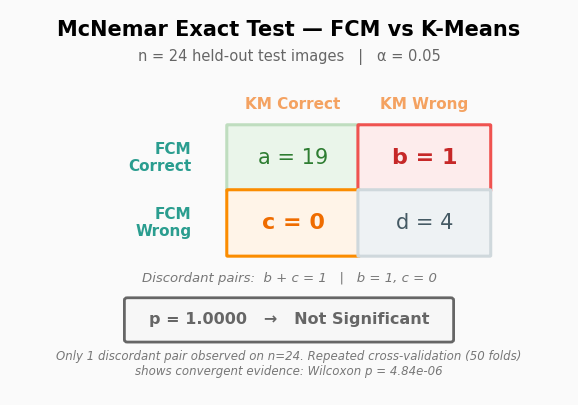

Saved → docs/fig_08a_mcnemar.png


In [ ]:
# =========================================================
# McNemar Exact Test — Refined Clean Version
# =========================================================

sig_str = (
    "Significant"
    if p_mcnemar < ALPHA
    else "Not Significant"
)

sig_col = (
    "#C62828"
    if p_mcnemar < ALPHA
    else "#666666"
)

# =========================================================
# FIGURE SETUP
# =========================================================

fig, ax = plt.subplots(
    figsize=(7.2, 5.0),
    facecolor=BG
)

ax.set_facecolor(BG)

ax.axis("off")

ax.set_xlim(0, 10)
ax.set_ylim(0, 8)

# =========================================================
# TITLE
# =========================================================

ax.text(
    5,
    7.45,

    "McNemar Exact Test — FCM vs K-Means",

    ha="center",

    fontsize=15,
    fontweight="bold"
)

ax.text(
    5,
    6.95,

    f"n = {N_TE} held-out test images   |   α = {ALPHA}",

    ha="center",

    fontsize=10.5,

    color="#666666"
)

# =========================================================
# TABLE POSITION
# =========================================================

TBL_X = 3.9
TBL_Y = 2.9

CW = 2.35
CH = 1.35

# =========================================================
# CELL FUNCTION
# =========================================================

def draw_cell(
    x,
    y,
    text,
    fc,
    ec,
    tc,
    fs=15,
    bold=False
):

    rect = mpatches.FancyBboxPatch(

        (x, y),

        CW,
        CH,

        boxstyle="round,pad=0.015",

        fc=fc,
        ec=ec,

        lw=2.2
    )

    ax.add_patch(rect)

    ax.text(
        x + CW/2,
        y + CH/2,

        text,

        ha="center",
        va="center",

        fontsize=fs,

        color=tc,

        fontweight="bold" if bold else "normal"
    )

# =========================================================
# COLUMN LABELS
# =========================================================

ax.text(
    TBL_X + CW/2,
    TBL_Y + 2*CH + 0.35,

    "KM Correct",

    ha="center",

    fontsize=11,
    fontweight="bold",

    color=C_KM
)

ax.text(
    TBL_X + 1.5*CW,
    TBL_Y + 2*CH + 0.35,

    "KM Wrong",

    ha="center",

    fontsize=11,
    fontweight="bold",

    color=C_KM
)

# =========================================================
# ROW LABELS
# =========================================================

ax.text(
    TBL_X - 0.65,
    TBL_Y + 1.5*CH,

    "FCM\nCorrect",

    ha="right",
    va="center",

    fontsize=11,
    fontweight="bold",

    color=C_FCM
)

ax.text(
    TBL_X - 0.65,
    TBL_Y + 0.5*CH,

    "FCM\nWrong",

    ha="right",
    va="center",

    fontsize=11,
    fontweight="bold",

    color=C_FCM
)

# =========================================================
# TABLE CELLS
# =========================================================

# a
draw_cell(
    TBL_X,
    TBL_Y + CH,

    f"a = {a_te}",

    fc="#EAF5EA",
    ec="#BFDDBF",
    tc="#2E7D32",

    fs=15
)

# b
draw_cell(
    TBL_X + CW,
    TBL_Y + CH,

    f"b = {b_te}",

    fc="#FDECEC",
    ec="#EF5350",
    tc="#C62828",

    fs=16,
    bold=True
)

# c
draw_cell(
    TBL_X,
    TBL_Y,

    f"c = {c_te}",

    fc="#FFF4E8",
    ec="#FB8C00",
    tc="#EF6C00",

    fs=16,
    bold=True
)

# d
draw_cell(
    TBL_X + CW,
    TBL_Y,

    f"d = {d_te}",

    fc="#EEF2F4",
    ec="#CFD8DC",
    tc="#455A64",

    fs=15
)

# =========================================================
# DISCORDANT NOTE
# =========================================================

ax.text(
    5,
    2.35,

    f"Discordant pairs:  b + c = {n_disc}   |   b = {b_te}, c = {c_te}",

    ha="center",

    fontsize=9.5,

    color="#777777",

    style="italic"
)

# =========================================================
# P-VALUE BOX
# =========================================================

PV_X = 2.1
PV_Y = 1.15

PV_W = 5.8
PV_H = 0.82

pv_box = mpatches.FancyBboxPatch(

    (PV_X, PV_Y),

    PV_W,
    PV_H,

    boxstyle="round,pad=0.05",

    fc="#F7F7F7",

    ec=sig_col,

    lw=2
)

ax.add_patch(pv_box)

ax.text(
    PV_X + PV_W/2,
    PV_Y + PV_H/2,

    f"p = {p_mcnemar:.4f}   →   {sig_str}",

    ha="center",
    va="center",

    fontsize=11.5,

    fontweight="bold",

    color=sig_col
)

# =========================================================
# INTERPRETATION NOTE
# =========================================================

note = (
    f"Only {n_disc} discordant pair observed on n={N_TE}. "
    f"Repeated cross-validation (50 folds)\n"
    f"shows convergent evidence: Wilcoxon p = {wil_p:.2e}"
)

ax.text(
    5,
    0.42,

    note,

    ha="center",

    fontsize=8.5,

    color="#777777",

    style="italic"
)

# =========================================================
# SAVE
# =========================================================

plt.savefig(
    "docs/fig_08a_mcnemar.png",
    dpi=240,
    bbox_inches="tight",
    facecolor=BG
)

plt.show()

print("Saved → docs/fig_08a_mcnemar.png")

---
## Fig 08b — Bootstrap CI + Permutation Test  (n=24)

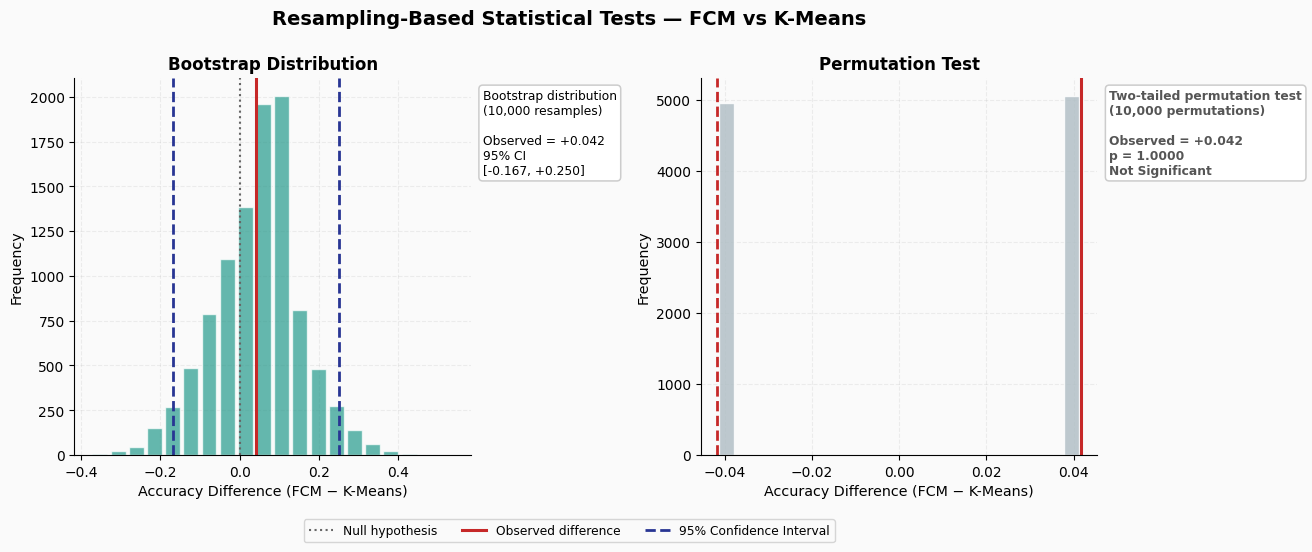

Saved → docs/fig_08b_bootstrap.png


In [ ]:
# =========================================================
# Resampling-Based Tests — IEEE Clean Layout
# Textboxes Outside Histogram Area
# =========================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(13.2, 4.9),
    facecolor=BG,

    # larger spacing for outside textboxes
    gridspec_kw={"wspace": 0.58}
)

fig.suptitle(
    "Resampling-Based Statistical Tests — FCM vs K-Means",
    fontsize=14,
    fontweight="bold",
    y=1.02
)

# =========================================================
# PANEL A — BOOTSTRAP DISTRIBUTION
# =========================================================

ax = axes[0]

# ---------------------------------------------------------
# Histogram
# ---------------------------------------------------------

ax.hist(
    bs_diffs,

    bins=20,

    rwidth=0.82,

    color=C_FCM,

    alpha=0.72,

    edgecolor="white"
)

# ---------------------------------------------------------
# Reference lines
# ---------------------------------------------------------

ax.axvline(
    0,

    color="#666666",

    lw=1.5,

    ls=":"
)

ax.axvline(
    obs_diff_te,

    color="#C62828",

    lw=2.2
)

ax.axvline(
    ci_lo,

    color="#283593",

    lw=2,

    ls="--"
)

ax.axvline(
    ci_hi,

    color="#283593",

    lw=2,

    ls="--"
)

# ---------------------------------------------------------
# Outside statistics textbox
# ---------------------------------------------------------

boot_txt = (
    "Bootstrap distribution\n"
    "(10,000 resamples)\n\n"
    f"Observed = {obs_diff_te:+.3f}\n"
    f"95% CI\n[{ci_lo:+.3f}, {ci_hi:+.3f}]"
)

ax.text(
    1.03,
    0.97,

    boot_txt,

    transform=ax.transAxes,

    ha="left",
    va="top",

    fontsize=8.8,

    bbox=dict(
        boxstyle="round,pad=0.32",

        fc="white",

        ec="#CCCCCC",

        lw=1.1
    ),

    clip_on=False
)

# ---------------------------------------------------------
# Axis styling
# ---------------------------------------------------------

ax.set_title(
    "Bootstrap Distribution",
    fontsize=12,
    fontweight="bold"
)

ax.set_xlabel(
    "Accuracy Difference (FCM − K-Means)",
    fontsize=10.3
)

ax.set_ylabel(
    "Frequency",
    fontsize=10.3
)

ax.grid(
    True,
    alpha=0.20,
    ls="--"
)

ax.set_axisbelow(True)

ax.spines[["top", "right"]].set_visible(False)

# =========================================================
# PANEL B — PERMUTATION TEST
# =========================================================

ax2 = axes[1]

# ---------------------------------------------------------
# Histogram
# ---------------------------------------------------------

ax2.hist(
    perm_diffs,

    bins=20,

    rwidth=0.82,

    color="#B0BEC5",

    alpha=0.82,

    edgecolor="white"
)

# ---------------------------------------------------------
# Reference lines
# ---------------------------------------------------------

ax2.axvline(
    obs_diff_te,

    color="#C62828",

    lw=2.2
)

ax2.axvline(
    -obs_diff_te,

    color="#C62828",

    lw=2,

    ls="--"
)

# ---------------------------------------------------------
# Significance interpretation
# ---------------------------------------------------------

sig_str = (
    "Significant"
    if p_perm < ALPHA
    else "Not Significant"
)

sig_col = (
    "#C62828"
    if p_perm < ALPHA
    else "#555555"
)

# ---------------------------------------------------------
# Outside statistics textbox
# ---------------------------------------------------------

perm_txt = (
    "Two-tailed permutation test\n"
    "(10,000 permutations)\n\n"
    f"Observed = {obs_diff_te:+.3f}\n"
    f"p = {p_perm:.4f}\n"
    f"{sig_str}"
)

ax2.text(
    1.03,
    0.97,

    perm_txt,

    transform=ax2.transAxes,

    ha="left",
    va="top",

    fontsize=8.8,

    fontweight="bold",

    color=sig_col,

    bbox=dict(
        boxstyle="round,pad=0.32",

        fc="white",

        ec="#CCCCCC",

        lw=1.1
    ),

    clip_on=False
)

# ---------------------------------------------------------
# Axis styling
# ---------------------------------------------------------

ax2.set_title(
    "Permutation Test",
    fontsize=12,
    fontweight="bold"
)

ax2.set_xlabel(
    "Accuracy Difference (FCM − K-Means)",
    fontsize=10.3
)

ax2.set_ylabel(
    "Frequency",
    fontsize=10.3
)

ax2.grid(
    True,
    alpha=0.20,
    ls="--"
)

ax2.set_axisbelow(True)

ax2.spines[["top", "right"]].set_visible(False)

# =========================================================
# GLOBAL LEGEND
# =========================================================

legend_handles = [

    mlines.Line2D(
        [],
        [],
        color="#666666",
        lw=1.5,
        ls=":",
        label="Null hypothesis"
    ),

    mlines.Line2D(
        [],
        [],
        color="#C62828",
        lw=2.2,
        label="Observed difference"
    ),

    mlines.Line2D(
        [],
        [],
        color="#283593",
        lw=2,
        ls="--",
        label="95% Confidence Interval"
    ),
]

fig.legend(
    handles=legend_handles,

    loc="lower center",

    bbox_to_anchor=(0.5, -0.08),

    ncol=3,

    frameon=True,

    fontsize=8.8
)

# =========================================================
# FINAL LAYOUT
# =========================================================

plt.tight_layout(
    rect=[0, 0.14, 1, 1]
)

plt.savefig(
    "docs/fig_08b_bootstrap.png",
    dpi=240,
    bbox_inches="tight",
    facecolor=BG
)

plt.show()

print("Saved → docs/fig_08b_bootstrap.png")

---
## Fig 08c — Statistical Validation Summary Table

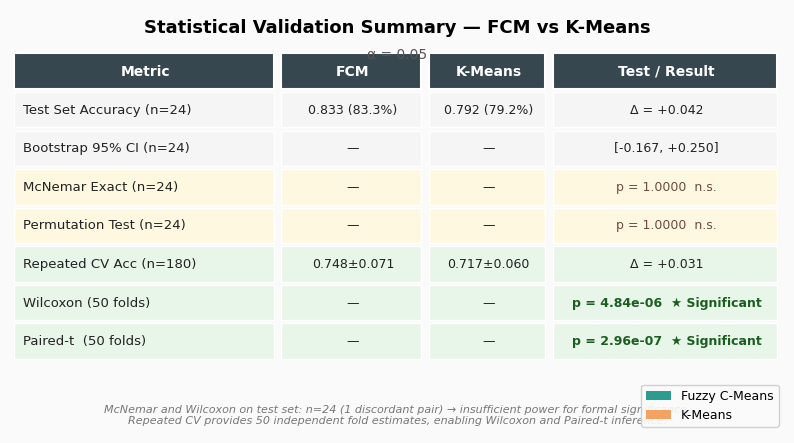

Saved → docs/fig_08c_summary.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5.5), facecolor=BG)
ax.set_facecolor(BG); ax.axis("off")
ax.set_xlim(0, 10); ax.set_ylim(0, 5.6)

ax.text(5, 5.3, "Statistical Validation Summary — FCM vs K-Means",
        ha="center", fontsize=13, fontweight="bold")
ax.text(5, 4.95, f"\u03b1 = {ALPHA}",
        ha="center", fontsize=10, color="#555")

rows = [
    ("Test Set Accuracy (n=24)",
     f"{fcm_acc_te:.3f} ({fcm_acc_te:.1%})",
     f"{km_acc_te:.3f} ({km_acc_te:.1%})",
     f"\u0394 = {obs_diff_te:+.3f}", "#F5F5F5"),
    ("Bootstrap 95% CI (n=24)", "\u2014", "\u2014",
     f"[{ci_lo:+.3f}, {ci_hi:+.3f}]", "#F5F5F5"),
    ("McNemar Exact (n=24)", "\u2014", "\u2014",
     f"p = {p_mcnemar:.4f}  n.s.", "#FFF8E1"),
    ("Permutation Test (n=24)", "\u2014", "\u2014",
     f"p = {p_perm:.4f}  n.s.", "#FFF8E1"),
    ("Repeated CV Acc (n=180)",
     f"{fold_fcm.mean():.3f}\u00b1{fold_fcm.std():.3f}",
     f"{fold_km.mean():.3f}\u00b1{fold_km.std():.3f}",
     f"\u0394 = {fold_diffs.mean():+.3f}", "#E8F5E9"),
    ("Wilcoxon (50 folds)", "\u2014", "\u2014",
     f"p = {wil_p:.2e}  \u2605 Significant", "#E8F5E9"),
    ("Paired-t  (50 folds)", "\u2014", "\u2014",
     f"p = {t_p:.2e}  \u2605 Significant", "#E8F5E9"),
]

headers  = ["Metric", "FCM", "K-Means", "Test / Result"]
col_x    = [0.05, 3.5,  5.4,  7.0]
col_w    = [3.4,  1.85, 1.55, 2.95]
ROW_H    = 0.47
Y0       = 4.55

for i, (hdr, cx, cw) in enumerate(zip(headers, col_x, col_w)):
    ax.add_patch(mpatches.FancyBboxPatch(
        (cx, Y0), cw-0.05, ROW_H,
        boxstyle="square,pad=0", fc="#37474F", ec="white", lw=1.5))
    ax.text(cx+cw/2, Y0+ROW_H/2, hdr,
            ha="center", va="center", fontsize=10, fontweight="bold", color="white")

for r_i, (m, fcm_v2, km_v2, res_v, bg) in enumerate(rows):
    ry   = Y0 - (r_i+1) * (ROW_H+0.04)
    vals = [m, fcm_v2, km_v2, res_v]
    for i, (val, cx, cw) in enumerate(zip(vals, col_x, col_w)):
        ax.add_patch(mpatches.FancyBboxPatch(
            (cx, ry), cw-0.05, ROW_H,
            boxstyle="square,pad=0", fc=bg, ec="white", lw=1.0))
        col = "#1B5E20" if "\u2605" in val else ("#6D4C41" if "n.s." in val else "#222")
        ax.text(cx+(0.12 if i==0 else cw/2), ry+ROW_H/2, val,
                ha=("left" if i==0 else "center"), va="center",
                fontsize=(9.5 if i==0 else 9), color=col,
                fontweight="bold" if "\u2605" in val else "normal")

ax.legend(handles=[
    mpatches.Patch(fc=C_FCM, label="Fuzzy C-Means"),
    mpatches.Patch(fc=C_KM,  label="K-Means"),
], loc="lower right", fontsize=9, framealpha=0.9)

note = (f"McNemar and Wilcoxon on test set: n={N_TE} (1 discordant pair) \u2192 insufficient power for formal significance.\n"
         "Repeated CV provides 50 independent fold estimates, enabling Wilcoxon and Paired-t inference.")
ax.text(5, 0.12, note, ha="center", fontsize=8, color="#777", style="italic")

plt.savefig("docs/fig_08c_summary.png", dpi=200, bbox_inches="tight", facecolor=BG)
plt.show()
print("Saved \u2192 docs/fig_08c_summary.png")